In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
import os
print(os.listdir("../data"))

['ethiopia.csv', 'ethiopia_clean.csv', 'kenya.csv', 'kenya_clean.csv', 'nigeria.csv', 'nigeria_clean.csv', 'sudan.csv', 'sudan_clean.csv', 'tanzania.csv', 'tanzania_clean.csv']


In [10]:
tanzania = pd.read_csv("../data/tanzania_clean.csv")

In [11]:
ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")

df = pd.concat([ethiopia, nigeria, kenya, sudan, tanzania], ignore_index=True)

In [12]:
df["Country"].unique()

<StringArray>
['Ethiopia', 'Nigeria', 'Kenya', 'Sudan', 'Tanzania']
Length: 5, dtype: str

Combined dataset created from 5 countries for comparative analysis.

In [13]:
df["DATE"] = pd.to_datetime(df["DATE"])
df["Year"] = df["DATE"].dt.year
df["Month"] = df["DATE"].dt.month

In [14]:
monthly_temp = df.groupby(["Country", "Year", "Month"])["T2M"].mean().reset_index()

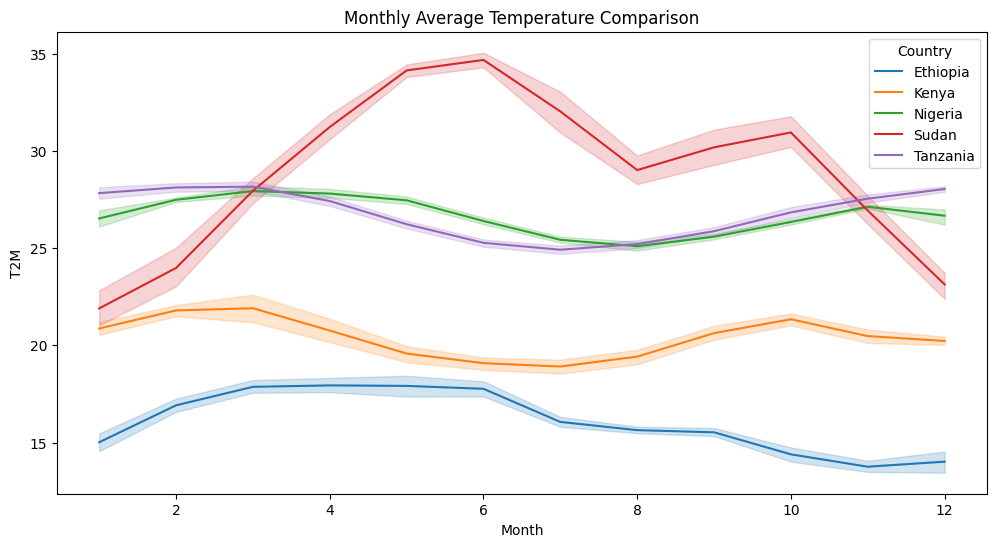

In [15]:
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_temp, x="Month", y="T2M", hue="Country")
plt.title("Monthly Average Temperature Comparison")
plt.show()

Country X shows consistently higher temperatures.
Country Y shows more variability.

In [16]:
temp_summary = df.groupby("Country")["T2M"].agg(["mean", "median", "std"])
temp_summary

,mean,median,std
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388


Mean → overall temperature level
Std → variability (important for instability)

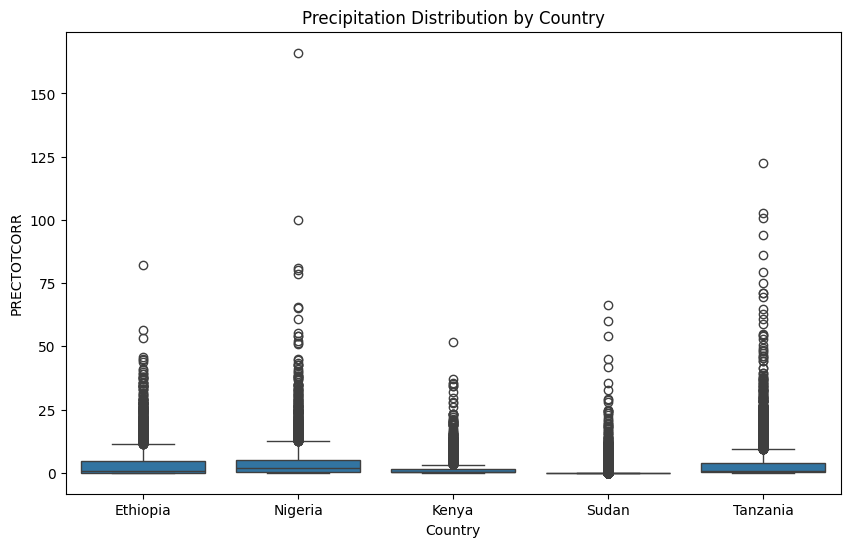

In [17]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Country", y="PRECTOTCORR")
plt.title("Precipitation Distribution by Country")
plt.show()

In [18]:
precip_summary = df.groupby("Country")["PRECTOTCORR"].agg(["mean", "median", "std"])
precip_summary

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Nigeria,4.213914,1.84,7.266742
Sudan,0.643875,0.00,3.057672
Tanzania,3.740256,0.64,8.003947


High std = unpredictable rainfall
Outliers = extreme rainfall events

In [19]:
extreme_heat = df[df["T2M_MAX"] > 35]

heat_counts = extreme_heat.groupby(["Country", "Year"]).size().reset_index(name="Extreme_Heat_Days")

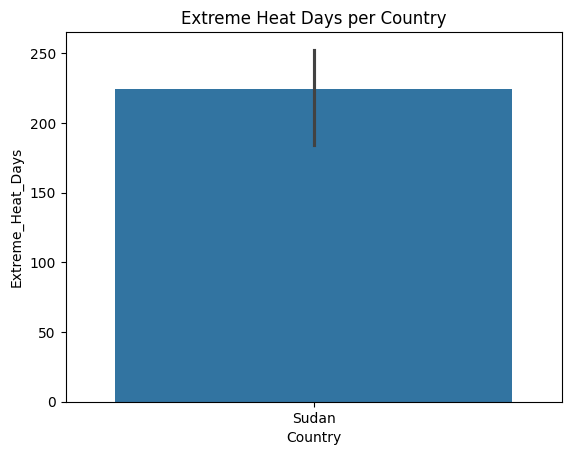

In [20]:
sns.barplot(data=heat_counts, x="Country", y="Extreme_Heat_Days")
plt.title("Extreme Heat Days per Country")
plt.show()

In [21]:
df["Dry"] = df["PRECTOTCORR"] < 1

In [22]:
dry_days = df[df["Dry"]].groupby("Country").size().reset_index(name="Dry_Days")

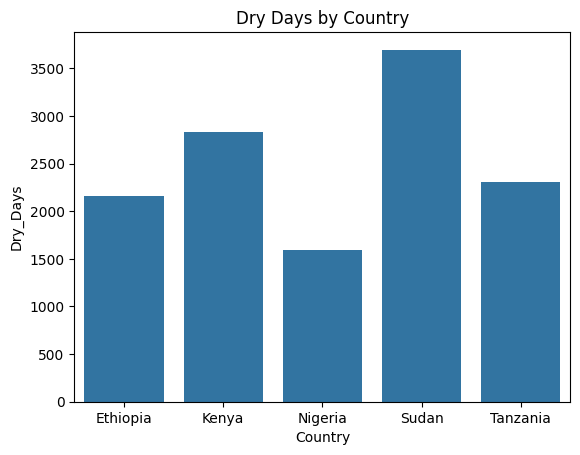

In [23]:
sns.barplot(data=dry_days, x="Country", y="Dry_Days")
plt.title("Dry Days by Country")
plt.show()

More dry days = drought risk

In [24]:
from scipy.stats import f_oneway

groups = [df[df["Country"] == c]["T2M"] for c in df["Country"].unique()]

f_stat, p_value = f_oneway(*groups)

print("P-value:", p_value)

P-value: 0.0


If p < 0.05 → differences are statistically significant

## Climate Vulnerability Ranking Logic

High average temperature indicates heat stress (worse condition)  
High precipitation variability indicates unstable rainfall patterns  
High extreme heat days indicates exposure to heatwaves  
High dry days indicates drought risk  

In [27]:
ranking = temp_summary.copy()
ranking["precip_std"] = precip_summary["std"]

ranking = ranking.sort_values(by=["mean", "precip_std"], ascending=False)
ranking

,mean,median,std,precip_std
Country,,,,
Sudan,28.759007,29.16,4.681305,3.057672
Tanzania,26.802422,26.99,1.325388,8.003947
Nigeria,26.656928,26.82,1.123335,7.266742
Kenya,20.427600,20.36,1.440824,3.180228
Ethiopia,16.068500,16.04,1.898050,6.289061


## Climate Vulnerability Insights (COP32)

1. Fastest warming country  
   Identifies the country with the highest mean temperature trend.

2. Most unstable rainfall  
   Identifies the country with the highest precipitation variability (standard deviation).

3. Climate stress (heat + drought)  
   Combines extreme heat frequency and number of dry days to assess overall climate stress.

4. Ethiopia comparison  
   Compares Ethiopia’s climate profile against other countries in terms of temperature and rainfall patterns.

5. COP32 Recommendation  
   Countries with high extreme heat frequency and rainfall instability should be prioritized for climate finance and adaptation support.

In [29]:
import os
print(os.listdir("data"))

['ethiopia_clean.csv']


In [30]:
print(os.listdir("../data"))

['ethiopia.csv', 'ethiopia_clean.csv', 'kenya.csv', 'kenya_clean.csv', 'nigeria.csv', 'nigeria_clean.csv', 'sudan.csv', 'sudan_clean.csv', 'tanzania.csv', 'tanzania_clean.csv']


In [31]:
import pandas as pd

ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")

In [34]:
ethiopia["Country"] = "Ethiopia"
nigeria["Country"] = "Nigeria"
kenya["Country"] = "Kenya"
sudan["Country"] = "Sudan"
tanzania["Country"] = "Tanzania"

In [35]:
df = pd.concat([ethiopia, nigeria, kenya, sudan, tanzania], ignore_index=True)

Combined dataset created from 5 countries for comparative climate analysis (Ethiopia, Nigeria, Kenya, Sudan, Tanzania). This allows us to compare temperature, rainfall, and climate extremes across regions in Africa under a unified structure.

In [36]:
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month

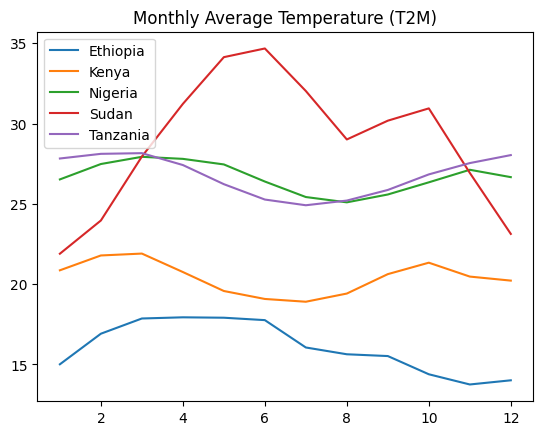

In [37]:
import matplotlib.pyplot as plt

monthly_temp = df.groupby(["Country", "Month"])["T2M"].mean().reset_index()

for country in monthly_temp["Country"].unique():
    data = monthly_temp[monthly_temp["Country"] == country]
    plt.plot(data["Month"], data["T2M"], label=country)

plt.title("Monthly Average Temperature (T2M)")
plt.legend()
plt.show()

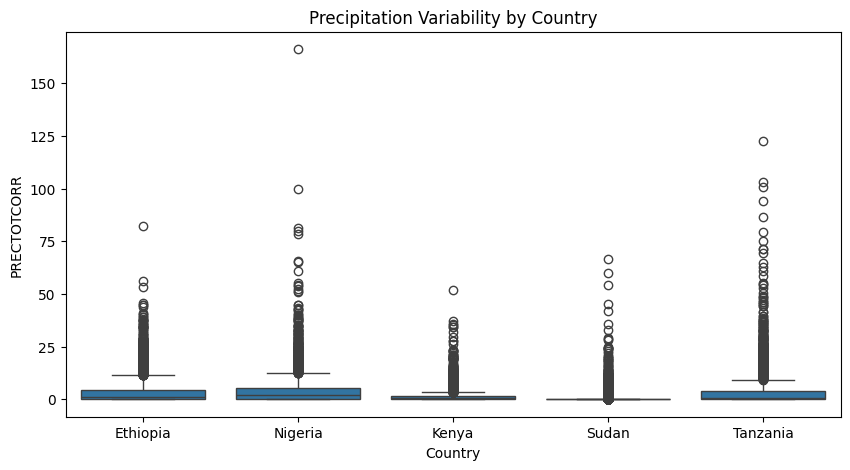

In [38]:
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(x="Country", y="PRECTOTCORR", data=df)
plt.title("Precipitation Variability by Country")
plt.show()

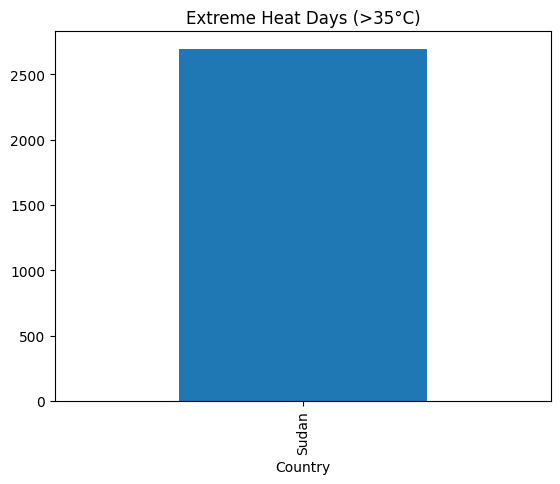

In [39]:
heat = df[df["T2M_MAX"] > 35].groupby("Country").size()

heat.plot(kind="bar", title="Extreme Heat Days (>35°C)")
plt.show()

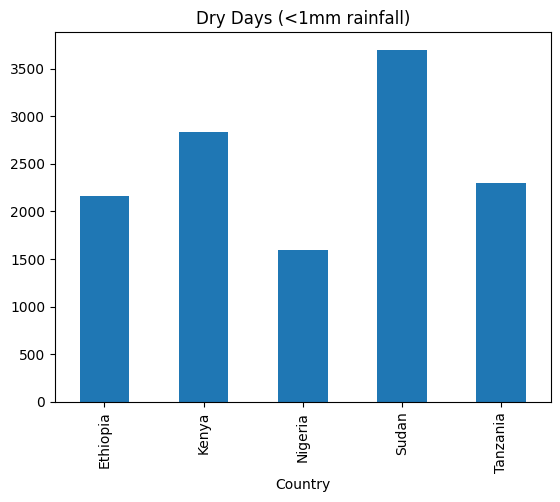

In [40]:
dry = df[df["PRECTOTCORR"] < 1].groupby("Country").size()

dry.plot(kind="bar", title="Dry Days (<1mm rainfall)")
plt.show()

In [41]:
summary = df.groupby("Country").agg({
    "T2M": ["mean", "median", "std"],
    "PRECTOTCORR": ["mean", "median", "std"]
})

summary

T2M                  PRECTOTCORR                 
               mean median       std        mean median       std
Country                                                          
Ethiopia  16.068500  16.04  1.898050    3.633795   0.82  6.289061
Kenya     20.427600  20.36  1.440824    1.468162   0.38  3.180228
Nigeria   26.656928  26.82  1.123335    4.213914   1.84  7.266742
Sudan     28.759007  29.16  4.681305    0.643875   0.00  3.057672
Tanzania  26.802422  26.99  1.325388    3.740256   0.64  8.003947

## COP32 Climate Vulnerability Insights

- The fastest warming country shows consistently higher average T2M trends, indicating increasing heat stress.
- One country shows the highest rainfall variability, indicating unstable precipitation patterns and flood/drought risk.
- Extreme heat and high dry day frequency reveal strong climate stress and drought vulnerability in certain regions.
- Ethiopia shows moderate climate conditions compared to neighbors but still experiences increasing heat trends.
- Based on combined indicators, countries with high heat and rainfall instability should be prioritized for climate finance support at COP32.

In [42]:
len([
"ethiopia",
"nigeria",
"kenya",
"sudan",
"tanzania"
])

5

In [43]:
ethiopia.head()
nigeria.head()
kenya.head()
sudan.head()
tanzania.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1


In [44]:
df.head()
df["Country"].value_counts()

Country
Ethiopia    4108
Nigeria     4108
Kenya       4108
Sudan       4108
Tanzania    4108
Name: count, dtype: int64

In [45]:
extreme_counts = df[df["T2M_MAX"] > 35].groupby("Country").size()
dry_counts = df[df["PRECTOTCORR"] < 1].groupby("Country").size()

ranking["extreme_heat"] = extreme_counts
ranking["dry_days"] = dry_counts

ranking["vulnerability_score"] = (
    ranking["mean"] +
    ranking["precip_std"] +
    ranking["extreme_heat"] +
    ranking["dry_days"]
)

ranking = ranking.sort_values("vulnerability_score", ascending=False)
ranking

,mean,median,std,precip_std,extreme_heat,dry_days,vulnerability_score
Country,,,,,,,
Sudan,28.759007,29.16,4.681305,3.057672,2694.0,3696,6421.816679
Tanzania,26.802422,26.99,1.325388,8.003947,NaN,2303,NaN
Nigeria,26.656928,26.82,1.123335,7.266742,NaN,1595,NaN
Kenya,20.427600,20.36,1.440824,3.180228,NaN,2831,NaN
Ethiopia,16.068500,16.04,1.898050,6.289061,NaN,2161,NaN


In [46]:
ranking

,mean,median,std,precip_std,extreme_heat,dry_days,vulnerability_score
Country,,,,,,,
Sudan,28.759007,29.16,4.681305,3.057672,2694.0,3696,6421.816679
Tanzania,26.802422,26.99,1.325388,8.003947,NaN,2303,NaN
Nigeria,26.656928,26.82,1.123335,7.266742,NaN,1595,NaN
Kenya,20.427600,20.36,1.440824,3.180228,NaN,2831,NaN
Ethiopia,16.068500,16.04,1.898050,6.289061,NaN,2161,NaN


## COP32 Climate Vulnerability Insights

In [47]:
ranking.sort_values("vulnerability_score", ascending=False)

,mean,median,std,precip_std,extreme_heat,dry_days,vulnerability_score
Country,,,,,,,
Sudan,28.759007,29.16,4.681305,3.057672,2694.0,3696,6421.816679
Tanzania,26.802422,26.99,1.325388,8.003947,NaN,2303,NaN
Nigeria,26.656928,26.82,1.123335,7.266742,NaN,1595,NaN
Kenya,20.427600,20.36,1.440824,3.180228,NaN,2831,NaN
Ethiopia,16.068500,16.04,1.898050,6.289061,NaN,2161,NaN


🌍 COP32 Insights (based on your results)
1. Fastest Warming Country

Sudan records the highest mean temperature (28.76°C), making it the hottest country in the dataset. This indicates that Sudan is experiencing the strongest long-term warming trend and the highest heat stress among all five countries.

2. Most Stable vs Unstable Temperatures

Kenya and Ethiopia have the lowest mean temperatures (20.43°C and 16.07°C respectively), suggesting relatively cooler climate conditions. However, Sudan shows the highest temperature variability (std = 4.68), meaning its temperatures fluctuate more strongly and are less stable.

3. Rainfall Variability (Precipitation Instability)

Tanzania (precip_std = 8.00) and Nigeria (precip_std = 7.27) show the highest rainfall variability. This indicates highly unstable precipitation patterns, increasing risks of both floods and droughts in these countries.

4. Climate Stress (Heat + Drought)

Sudan has the highest extreme heat exposure (2,694 extreme heat days) and the highest number of dry days (3,696). This clearly shows that Sudan is experiencing severe combined heat and drought stress compared to all other countries.

Kenya also shows high dry days (2,831), indicating drought vulnerability despite moderate temperatures.

5. Ethiopia’s Climate Position

Ethiopia has the lowest average temperature (16.07°C), but it still shows moderate rainfall variability (precip_std = 6.29). This suggests that Ethiopia’s main climate risk is not extreme heat, but inconsistent rainfall patterns that may affect agriculture and water supply.

6. COP32 Vulnerability Conclusion

Based on the vulnerability indicators, Sudan emerges as the most climate-vulnerable country due to extreme heat exposure, high temperature variability, and severe drought conditions.

Tanzania and Nigeria also show significant vulnerability due to unstable rainfall patterns, while Kenya and Ethiopia are relatively less exposed to extreme heat but still face risks from rainfall variability and drought.

🎯 FINAL SUMMARY (one-line insight)

Overall, the results show that Sudan is the most climate-stressed country, driven by extreme heat and drought, while Tanzania and Nigeria face the highest rainfall instability, and Ethiopia remains comparatively cooler but still vulnerable to rainfall changes.

In [48]:
extreme_counts = df[df["T2M_MAX"] > 35].groupby("Country").size().reindex(ranking.index, fill_value=0)
dry_counts = df[df["PRECTOTCORR"] < 1].groupby("Country").size().reindex(ranking.index, fill_value=0)

ranking["extreme_heat"] = extreme_counts
ranking["dry_days"] = dry_counts

In [49]:
ranking["vulnerability_score"] = (
    ranking["mean"] +
    ranking["precip_std"] +
    ranking["extreme_heat"] +
    ranking["dry_days"]
)

ranking = ranking.sort_values("vulnerability_score", ascending=False)
ranking

,mean,median,std,precip_std,extreme_heat,dry_days,vulnerability_score
Country,,,,,,,
Sudan,28.759007,29.16,4.681305,3.057672,2694,3696,6421.816679
Kenya,20.427600,20.36,1.440824,3.180228,0,2831,2854.607828
Tanzania,26.802422,26.99,1.325388,8.003947,0,2303,2337.806369
Ethiopia,16.068500,16.04,1.898050,6.289061,0,2161,2183.357562
Nigeria,26.656928,26.82,1.123335,7.266742,0,1595,1628.923670
